In [2]:
%matplotlib inline

# Check the ensemble simulation results for HBR
# and find the best parameter set for runoff and LAI
import os
import sys
sys.path.append(os.path.join(os.environ['HOME'], 'models', 'OLMT'))

import pickle
import model_ELM
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from shared_read_HBR import *

file = open(os.path.join(os.environ['HOME'], 'models', 'OLMT', 'pklfiles',
                         '20250429_HBR_ICB20TRCNPRDCTCBC_erw.pkl'), 'rb')
model = pickle.load(file)

In [3]:
tlai_rmse = np.sqrt(np.sum(np.power(model.output['TLAI_ann'] - \
                                    model.obs['TLAI_ann'].reshape(-1,1), 2), axis = 0))
runoff_rmse = np.sqrt(np.sum(np.power(model.output['QRUNOFF_ann'] - \
                                      model.obs['QRUNOFF_ann'].reshape(-1,1), 2), axis = 0))

best_ind = np.argmin(tlai_rmse**2 + runoff_rmse**2)
print('ensemble = ', best_ind+1)

ensemble =  2883


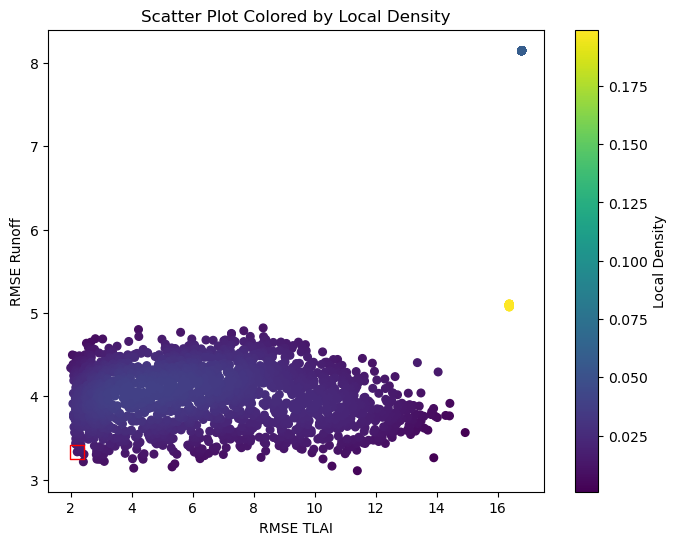

In [4]:
data = np.vstack([tlai_rmse, runoff_rmse]).T

kde = gaussian_kde(data.T)
densities = kde(data.T)

# Sort the points by density for better coloring
idx = densities.argsort()
x, y = data[idx, 0], data[idx, 1]
densities = densities[idx]

# Plot
fig, ax = plt.subplots(figsize = (8, 6))
scatter = ax.scatter(x, y, c=densities, s=30, cmap='viridis')
ax.scatter(tlai_rmse[best_ind], runoff_rmse[best_ind], s=100, color = 'r', 
           facecolor = 'none', marker = 's')
plt.colorbar(scatter, ax = ax, label='Local Density')
ax.set_xlabel('RMSE TLAI')
ax.set_ylabel('RMSE Runoff')
ax.set_title('Scatter Plot Colored by Local Density')
plt.savefig(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'HBR_calibration.png'), 
            dpi = 600.)
plt.show()

Text(0.5, 1.0, 'Runoff cycle (mm/day)')

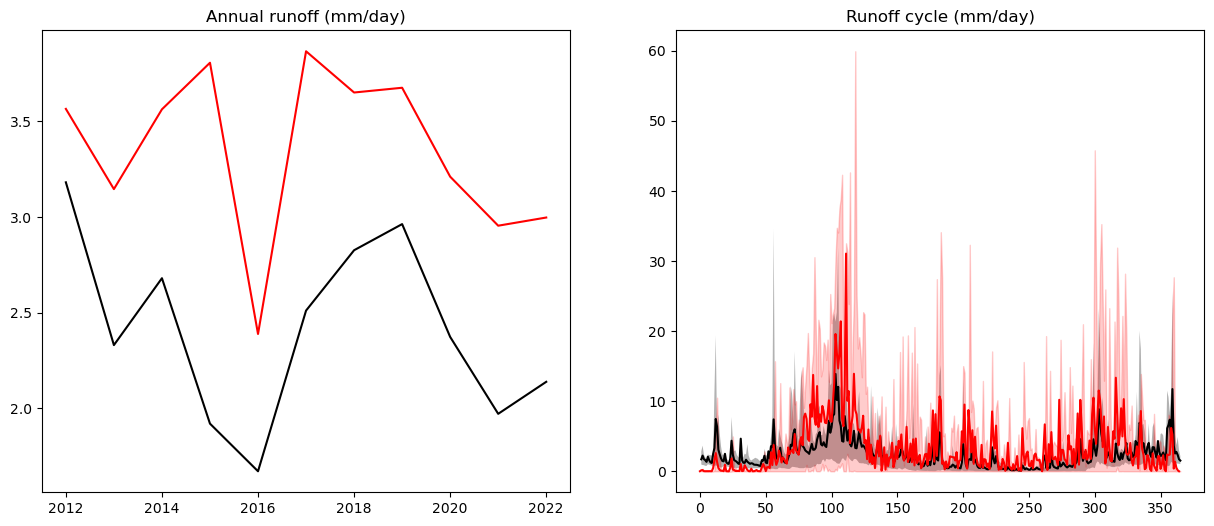

In [32]:
runoff_obs = read_runoff() # mm/day
runoff_obs = runoff_obs.loc[(runoff_obs.index.year >= 2012) & (runoff_obs.index.year <= 2022)]
runoff_obs = runoff_obs.loc[(runoff_obs.index.month != 2) | (runoff_obs.index.day != 29)]


fig, axes = plt.subplots(1, 2, figsize = (15, 6))

ax = axes.flat[0]
obs_ann = runoff_obs.resample('1Y').mean()
ax.plot(range(2012,2023), obs_ann, '-k')

ax.plot(range(2012,2023), model.output['QRUNOFF_ann'][:, best_ind], '-r')
ax.set_title('Annual runoff (mm/day)')

ax = axes.flat[1]

obs_box = runoff_obs.values.reshape(-1, 365)
ax.plot(range(1, 366), obs_box.mean(axis = 0), '-k', label = 'Observed')
ax.fill_between(
    range(1, 366),
    np.nanpercentile(obs_box, 10, axis = 0),
    np.nanpercentile(obs_box, 90, axis = 0), 
    fc = 'k', alpha = 0.3
)

temp = model.output['QRUNOFF'][:, best_ind].reshape(-1,365)*86400
ax.plot(temp.mean(axis = 0), 'r')
ax.fill_between(
    np.arange(1, 366),
    np.quantile(temp, 0.1, axis = 0), 
    np.quantile(temp, 0.9, axis = 0), alpha = 0.2, color = 'r')
ax.set_title('Runoff cycle (mm/day)')

Text(0.5, 1.0, 'Annual maximum leaf area index')

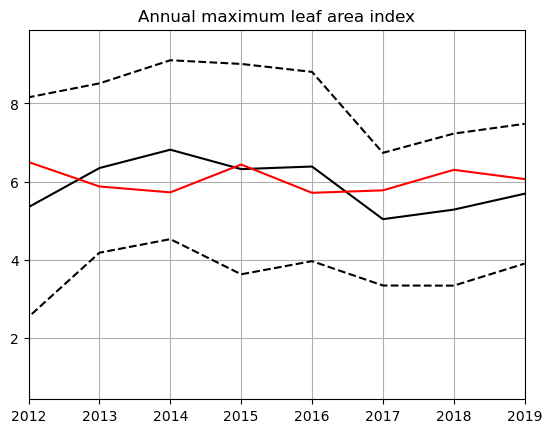

In [30]:
lai_obs = read_lai()
lai_obs_mean = lai_obs.groupby('Year').mean()
lai_obs_std = lai_obs.groupby('Year').std()

fig, ax = plt.subplots()
ax.plot(lai_obs_mean.index, lai_obs_mean, '-k', label = 'Observed')
ax.plot(lai_obs_std.index, lai_obs_mean - 2*lai_obs_std, '--k')
ax.plot(lai_obs_std.index, lai_obs_mean + 2*lai_obs_std, '--k')
ax.plot(range(2012,2020), model.output['TLAI_ann'][:, best_ind], '-r', label = 'Modeled')
ax.set_xlim([2012, 2019])
ax.set_xticks(range(2012, 2020))
ax.grid(True)
ax.set_title('Annual maximum leaf area index')

/tmp/ipykernel_478028/3041172705.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1, 13))


Text(0.0, 1.02, '(e)')

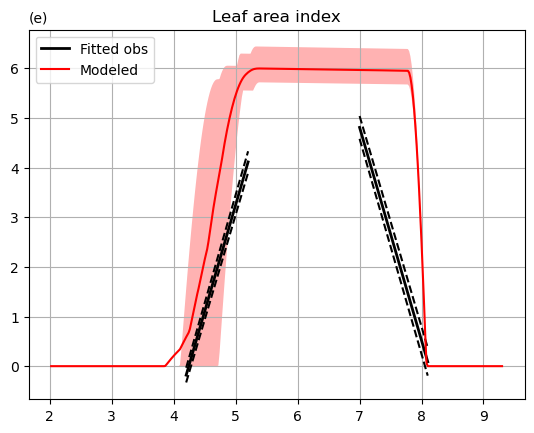

In [37]:
spr, fal = read_pheno()
slope_spr, intercept_spr, slope_std_spr = spr
slope_fal, intercept_fal, slope_std_fal = fal


data = model.output['TLAI'][:, best_ind].reshape(-1, 365)

fig, ax = plt.subplots()
ax.plot([110, 160], [110*slope_spr + intercept_spr, 
                     160*slope_spr + intercept_spr], '-k', lw = 2, 
        label = 'Fitted obs')
ax.plot([110, 160], [110*(slope_spr + slope_std_spr) + intercept_spr, 
                     160*(slope_spr + slope_std_spr) + intercept_spr], '--k')
ax.plot([110, 160], [110*(slope_spr - slope_std_spr) + intercept_spr, 
                     160*(slope_spr - slope_std_spr) + intercept_spr], '--k')
ax.plot([250, 305], [250*slope_fal + intercept_fal, 
                     305*slope_fal + intercept_fal], '-k', lw = 2)
ax.plot([250, 305], [250*(slope_fal + slope_std_fal) + intercept_fal, 
                     305*(slope_fal + slope_std_fal) + intercept_fal], '--k')
ax.plot([250, 305], [250*(slope_fal - slope_std_fal) + intercept_fal, 
                     305*(slope_fal - slope_std_fal) + intercept_fal], '--k')
ax.plot(range(1, 366), data.mean(axis = 0), '-r', label = 'Modeled')
ax.fill_between(
    range(1, 366),
    np.nanpercentile(data, 10, axis = 0),
    np.nanpercentile(data, 90, axis = 0), 
    fc = 'r', alpha = 0.3
)
ax.legend(loc = 'upper left')
ax.set_title('Leaf area index')
ax.grid(True)
ax.set_xticklabels(range(1, 13))
ax.text(0., 1.02, '(e)', transform = ax.transAxes)